In [1]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [6]:
cube = connection.datacube_from_process(
    "sentinel1_sar_coherence",
    namespace="https://raw.githubusercontent.com/ESA-APEx/apex_algorithms/main/algorithm_catalog/eurac/sentinel1_sar_coherence/openeo_udp/sentinel1_sar_coherence.json",
    temporal_extent=["2023-04-01", "2023-09-30"],
    temporal_baseline=12,
    spatial_extent={
        "west": 5.55,
        "south": 52.55,
        "east": 5.65,
        "north": 52.60
        },
    polarization= "VH",
    sub_swath="IW2",
)

In [5]:
job = cube.create_job(title="SAR coherence")
job.start_and_wait()

In [4]:
results = job.get_results()
results.download_files("coherence/")

[WindowsPath('coherence/openEO_2023-04-12Z.tif'),
 WindowsPath('coherence/openEO_2023-04-24Z.tif'),
 WindowsPath('coherence/openEO_2023-05-06Z.tif'),
 WindowsPath('coherence/openEO_2023-05-18Z.tif'),
 WindowsPath('coherence/openEO_2023-05-30Z.tif'),
 WindowsPath('coherence/openEO_2023-06-11Z.tif'),
 WindowsPath('coherence/openEO_2023-06-23Z.tif'),
 WindowsPath('coherence/openEO_2023-07-05Z.tif'),
 WindowsPath('coherence/openEO_2023-07-17Z.tif'),
 WindowsPath('coherence/openEO_2023-07-29Z.tif'),
 WindowsPath('coherence/openEO_2023-08-10Z.tif'),
 WindowsPath('coherence/openEO_2023-08-22Z.tif'),
 WindowsPath('coherence/openEO_2023-09-03Z.tif'),
 WindowsPath('coherence/openEO_2023-09-15Z.tif'),
 WindowsPath('coherence/job-results.json')]

In [1]:
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import xarray as xr 

In [2]:
tif_path = sorted(glob.glob("coherence/*.tif"))
if not tif_path:
        raise FileNotFoundError(f"No .tif files found in 'coherence/' - run the download cell above first.")
else:
    print(f"Found {len(tif_path)} .tif files in 'coherence/' folder")

Found 14 .tif files in 'coherence/' folder


In [3]:
# Stack all VH-coherence GeoTIFFs into one (t, y, x) cube
slices, timestamps = [], []
transform, crs = None, None
for tif in tif_path:
    with rasterio.open(tif) as src:
        data = src.read(1)
        transform = src.transform
        crs = src.crs
        slices.append(data)
        timestamps.append(Path(tif).stem.split("_")[-1])
        print(f"Read {tif} with shape {data.shape} and timestamp {timestamps[-1]}")

print(f"Stacking {len(slices)} slices into a single xarray DataArray siz")

C:\Users\SHARMAP\AppData\Local\Temp\ipykernel_26840\2468601324.py:6: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data = src.read(1)


Read coherence\openEO_2023-04-12Z.tif with shape (5076, 10640) and timestamp 2023-04-12Z
Read coherence\openEO_2023-04-24Z.tif with shape (5076, 10640) and timestamp 2023-04-24Z
Read coherence\openEO_2023-05-06Z.tif with shape (5076, 10640) and timestamp 2023-05-06Z
Read coherence\openEO_2023-05-18Z.tif with shape (5076, 10640) and timestamp 2023-05-18Z
Read coherence\openEO_2023-05-30Z.tif with shape (5076, 10640) and timestamp 2023-05-30Z
Read coherence\openEO_2023-06-11Z.tif with shape (5076, 10640) and timestamp 2023-06-11Z
Read coherence\openEO_2023-06-23Z.tif with shape (5076, 10640) and timestamp 2023-06-23Z
Read coherence\openEO_2023-07-05Z.tif with shape (5076, 10640) and timestamp 2023-07-05Z
Read coherence\openEO_2023-07-17Z.tif with shape (5076, 10640) and timestamp 2023-07-17Z
Read coherence\openEO_2023-07-29Z.tif with shape (5076, 10640) and timestamp 2023-07-29Z
Read coherence\openEO_2023-08-10Z.tif with shape (5076, 10640) and timestamp 2023-08-10Z
Read coherence\openEO

In [4]:
height, width = slices[0].shape
x_coords = transform.c + (np.arange(width) + 0.5) * transform.a
y_coords = transform.f + (np.arange(height) + 0.5) * transform.e
order = np.argsort([t if pd.notna(t) else pd.Timestamp.min for t in timestamps])
times_sorted = pd.to_datetime([timestamps[i].rstrip("Z") for i in order])
print(f"Sorted timestamps: {times_sorted.tolist()}")

Sorted timestamps: [Timestamp('2023-04-12 00:00:00'), Timestamp('2023-04-24 00:00:00'), Timestamp('2023-05-06 00:00:00'), Timestamp('2023-05-18 00:00:00'), Timestamp('2023-05-30 00:00:00'), Timestamp('2023-06-11 00:00:00'), Timestamp('2023-06-23 00:00:00'), Timestamp('2023-07-05 00:00:00'), Timestamp('2023-07-17 00:00:00'), Timestamp('2023-07-29 00:00:00'), Timestamp('2023-08-10 00:00:00'), Timestamp('2023-08-22 00:00:00'), Timestamp('2023-09-03 00:00:00'), Timestamp('2023-09-15 00:00:00')]


In [5]:
stacked_array = xr.DataArray(
    data=np.stack(slices, axis=0)[order],
    coords={
        "time": times_sorted,
        "y": y_coords,
        "x": x_coords
    },
    dims=["time", "y", "x"],
    attrs={
        "crs": str(crs),
        "transform": transform
    }
)

In [6]:
Z_THRESHOLD = 2.0
def detect_harvest(coh_vh: xr.DataArray) -> xr.Dataset:
    """VH-only adaptation of coherence_udf.py's change-point logic: the full
    UDF also uses VV coherence for a VH/VV canopy-density ratio, which isn't
    available from today's VH-only job - replaced here with a VH-only
    seasonal-mean-coherence proxy."""
    diff = coh_vh.diff("time")
    z = (diff - diff.mean("time")) / (diff.std("time") + 1e-6)
    print(f"Computed z-scores for {diff.shape[0]} time steps, with mean {z.mean().values:.4f} and std {z.std().values:.4f}")
    doy = xr.DataArray(diff["time"].dt.dayofyear.values, dims="time", coords={"time": diff["time"]})
    candidate_doy = doy.where(z > Z_THRESHOLD)
    print(f"Identified {candidate_doy.count().values} candidate harvest days with z-score > {Z_THRESHOLD}")
    return xr.Dataset({
        "harvest_doy": candidate_doy.min(dim="time", skipna=True),
        "max_jump_zscore": z.max(dim="time", skipna=True),
        "mean_vh_coherence": coh_vh.mean(dim="time", skipna=True),
    })

vegetation_result = detect_harvest(stacked_array)


Computed z-scores for 13 time steps, with mean -0.0000 and std 0.6993
Identified 3588458 candidate harvest days with z-score > 2.0


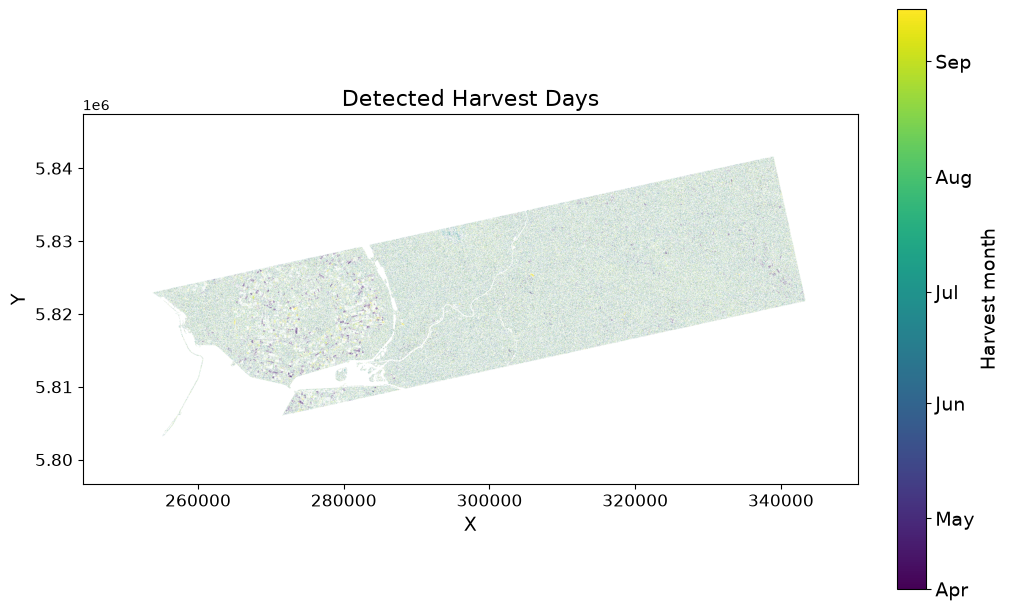

In [11]:
import matplotlib.pyplot as plt

harvest_doy = np.ma.masked_invalid(vegetation_result["harvest_doy"].values)
time_values = pd.to_datetime(stacked_array.time.values)
start_day = time_values.min().dayofyear
end_day = time_values.max().dayofyear
month_dates = pd.date_range(
    time_values.min().replace(day=1), time_values.max(), freq="MS"
)
month_days = [max(start_day, date.dayofyear) for date in month_dates]
month_labels = [date.strftime("%b") for date in month_dates]
extent = [
    stacked_array.x.min(), stacked_array.x.max(),
    stacked_array.y.min(), stacked_array.y.max()
]

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
image = ax.imshow(
    harvest_doy,
    extent=extent,
    origin="lower",
    vmin=start_day,
    vmax=end_day,
    cmap="viridis"
)
cbar = fig.colorbar(image, ax=ax, ticks=month_days)
cbar.ax.set_yticklabels(month_labels, fontsize=14)
cbar.set_label("Harvest month", fontsize=14)
cbar.ax.tick_params(labelsize=14)
ax.set_title("Detected Harvest Days", fontsize=16)
ax.set_xlabel("X", fontsize=14)
ax.set_ylabel("Y", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
plt.show()

C:\Users\SHARMAP\AppData\Local\Temp\ipykernel_26840\951688968.py:20: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  harvest_date = pd.Timestamp("2023-01-01") + pd.Timedelta(days=doy - 1)


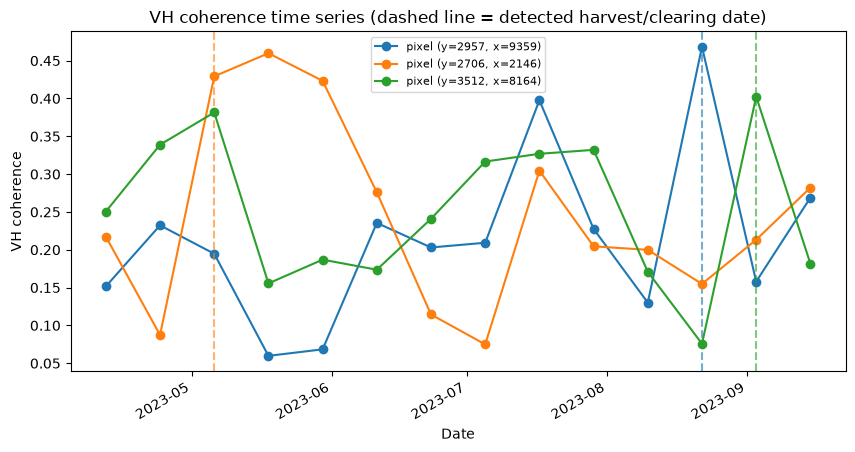

In [16]:
# Sample up to 3 pixels that have detected harvest dates
rng = np.random.default_rng(0)
ys, xs = np.where(np.isfinite(vegetation_result["harvest_doy"].values))

if len(ys) == 0:
    print("No pixel crossed the z-score threshold - showing the AOI center pixel instead.")
    sample_idx = [(stacked_array.sizes["y"] // 2, stacked_array.sizes["x"] // 2)]
else:
    pick = rng.choice(len(ys), size=min(3, len(ys)), replace=False)
    sample_idx = list(zip(ys[pick], xs[pick]))

# Plot time series for sampled pixels with harvest date markers
fig, ax = plt.subplots(figsize=(10, 5))
for y, x in sample_idx:
    series = stacked_array.isel(y=int(y), x=int(x))
    line, = ax.plot(series["time"].values, series.values, marker="o", label=f"pixel (y={y}, x={x})")
    
    doy = vegetation_result["harvest_doy"].isel(y=int(y), x=int(x)).item()
    if np.isfinite(doy):
        harvest_date = pd.Timestamp("2023-01-01") + pd.Timedelta(days=doy - 1)
        ax.axvline(harvest_date, color=line.get_color(), linestyle="--", alpha=0.6)

ax.set_ylabel("VH coherence")
ax.set_xlabel("Date")
ax.set_title("VH coherence time series (dashed line = detected harvest/clearing date)")
ax.legend(fontsize=8)
fig.autofmt_xdate()
plt.show()